In [ ]:
"""

Audio (Gradio)
   ↓
Whisper (OpenAI SDK 1.x)
   ↓
LCEL RAG Chain
   ↓
FAISS Retriever
   ↓
ChatOpenAI
   ↓
Answer
   ↓
Gradio UI (unchanged)

"""

In [ ]:
# openai 및 python-dotenv 라이브러리 설치
# openai는 OpenAI API와 상호 작용하는 데 사용됩니다.
# python-dotenv는 .env 파일에서 환경 변수를 로드하는 데 사용됩니다 (이 특정 코드에서는 사용되지 않음).
!pip install openai python-dotenv

In [ ]:
!pip install -q -U openai
!pip install -q -U langchain langchain-core langchain-community langchain-openai
!pip install -q -U faiss-cpu gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.6/561.6 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 74.1 MB/s eta 0:00:00


In [ ]:
# =========================================================
# [VOICE RAG AGENT - WHISPER + FAISS + LCEL + GRADIO]
# =========================================================
# 역할:
# 1. 음성 입력을 텍스트로 변환 (Whisper STT)
# 2. 변환된 텍스트를 RAG Query로 사용
# 3. FAISS에서 관련 문서 검색
# 4. LCEL 기반 Chain으로 답변 생성
# 5. Gradio UI로 통합 제공
# =========================================================


# =========================
# 1. 라이브러리 임포트
# =========================
# [MODIFIED] 최신 LangChain LCEL 기준
import os
import gradio as gr
from openai import OpenAI
from google.colab import userdata

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_community.vectorstores import FAISS


# =========================
# 2. OpenAI Client (Whisper STT)
# =========================
# 역할:
# - 음성 → 텍스트 변환 담당 Agent (STT Agent)
# - Whisper API 호출 전용 모듈

from google.colab import userdata
import os

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
client = OpenAI()

def speech_to_text(audio_path):
    # 역할: Whisper STT Agent (음성 → 텍스트 변환)
    with open(audio_path, "rb") as f:
        result = client.audio.transcriptions.create(
            model = "whisper-1",
            file = f
        )

    return result.text


# =========================
# 3. Embedding & Vector DB (FAISS Retriever Agent)
# =========================
# 역할:
# - 사용자 질문 기반 문서 검색 수행
# - RAG Context 생성 담당 Agent

embeddings = OpenAIEmbeddings()



# [MODIFIED] SKALA 실무 안정성 패치
# - FAISS index 없을 경우 자동 생성
# - runtime crash 방지

FAISS_INDEX_PATH = "faiss_index"



if os.path.exists(FAISS_INDEX_PATH):
    # =========================
    # [ORIGINAL LOGIC - 유지]
    # 기존: 무조건 load_local
    # =========================
    vectorstore = FAISS.load_local(
        FAISS_INDEX_PATH,
        embeddings,
        allow_dangerous_deserialization=True
    )

else:
    # =========================
    # [NEW LOGIC - 추가]
    # 인덱스 없을 경우 자동 생성 (RAG bootstrap)
    # =========================

    print("[INFO] FAISS index not found. Creating new index...")

    # [TEST DATA] 실제 프로젝트에서는 문서로 교체 필요
    texts = [
        "LangChain은 LLM 애플리케이션을 만드는 프레임워크이다.",
        "FAISS는 벡터 검색을 위한 라이브러리이다.",
        "Whisper는 음성을 텍스트로 변환한다.",
        "RAG는 검색 기반 생성 모델이다."
    ]

    vectorstore = FAISS.from_texts(
        texts = texts,
        embedding = embeddings
    )


    vectorstore.save_local(FAISS_INDEX_PATH)


# =========================
# Retriever Agent
# =========================
# 역할:
# - 검색 결과 반환 (RAG Context 생성)

retriever = vectorstore.as_retriever(search_kwargs={"k":3})


def format_docs(docs):
    # 역할: 검색된 문서를 LLM 입력용 Context로 변환
    return "\n\n".join([d.page_content for d in docs])

# =========================
# 4. Prompt Template (RAG Instruction Layer)
# =========================
# 역할:
# - LLM이 답변 생성 시 따라야 할 규칙 정의

prompt = ChatPromptTemplate.from_template("""
너는 RAG 기반 AI 어시스턴트이다.

[컨텍스트]
{context}

[질문]
{question}

규칙:
- 컨텍스트를 우선 사용
- 컨텍스트가 부족하면 일반 지식으로 보완 가능
- 단, 과도한 추측은 금지
- 답변은 자연스럽게 작성
""")


# =========================
# 5. LLM (Answer Generator Agent)
# =========================
# 역할:
# - 최종 답변 생성 Agent

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)


# =========================
# 6. LCEL RAG CHAIN (Core Pipeline)
# =========================
# 역할:
# - Retriever + Prompt + LLM 연결하는 핵심 Agent Pipeline

rag_chain = (
    {
        "context": retriever | format_docs,
        "question": RunnablePassthrough()
    }
    | prompt
    | llm
    | StrOutputParser()
)


# =========================
# 7. VOICE → RAG PIPELINE (Orchestrator Agent)
# =========================
# 역할:
# - 전체 Agent Workflow 제어
# - STT → RAG → Answer 통합 실행

def voice_rag_pipeline(audio_path):
    # Step 1: Whisper STT Agent 실행
    question = speech_to_text(audio_path)

    # Step 2: LCEL RAG Chain 실행
    answer = rag_chain.invoke(question)

    # Step 3: Gradio Output 반환
    return question, answer


# =========================
# 8. GRADIO UI (UNCHANGED RULE)
# =========================
# 역할:
# - 사용자 인터페이스
# - 절대 구조 변경 금지 (형 규칙)

demo = gr.Interface(
    fn=voice_rag_pipeline,
    inputs=gr.Audio(type="filepath", label="음성 입력"),
    outputs=[
        gr.Textbox(label="Whisper 변환 텍스트"),
        gr.Textbox(label="RAG 답변")
    ],
    title="Voice RAG Agent (Whisper + FAISS + LCEL)"
)

demo.launch()

/tmp/ipykernel_1032/2257988337.py:26: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


[INFO] FAISS index not found. Creating new index...
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a636495fdad4a1c070.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Gradio, OpenAI 설치
!pip install gradio --quiet
!pip install -U openai

음성파일 url
- https://www.darakwon.co.kr/mp3/FileDown_kor2.asp?p_id=8085&pf_type=5

In [ ]:
import openai
import gradio as gr
import os
from openai import OpenAI
from google.colab import userdata


# =========================================================
# OpenAI API KEY 설정 (형 코드 유지)
# =========================================================
# 역할:
# - Colab 환경에서 안전하게 OpenAI API Key를 환경변수로 주입
# - 이후 OpenAI client에서 자동 참조하도록 구성

os.environ['OPENAI_API_KEY'] = userdata.get("OPENAI_API_KEY")


# =========================================================
# OpenAI Client 초기화 (최신 SDK 방식)
# =========================================================
# 역할:
# - Whisper API (transcription / translation) 호출을 위한 클라이언트 객체 생성
# - OpenAI 최신 SDK 기준 (openai>=1.x)

api_key = os.getenv("OPENAI_API_KEY")

# API Key 존재 여부 검증 (실무 안정성 필수)
if not api_key:
    raise ValueError("OPENAI_API_KEY가 설정되지 않았습니다. Colab userdata를 확인하세요.")

# OpenAI 클라이언트 생성
client = OpenAI(api_key=api_key)


# =========================================================
# 음성 전사 함수 (Speech to Text)
# =========================================================
# 역할:
# - Whisper 모델을 사용하여 음성 파일을 텍스트로 변환
# - 입력: audio_path (파일 경로)
# - 출력: 변환된 텍스트 또는 에러 메시지

def transcribe_audio(audio_path):

    try:
        # 음성 파일을 바이너리 모드로 열기
        with open(audio_path, 'rb') as f:

            # Whisper transcription API 호출
            result = client.audio.transcriptions.create(
                model = "whisper-1",
                file = f
            )

        # 변환 결과 반환
        return result.text

    except Exception as e:

        # 에러 발생 시 traceback 전체 반환 (디버깅 목적)
        import traceback
        return f"[TRANSCRIBE ERROR]\n{traceback.format_exc()}"


# =========================================================
# 음성 번역 함수 (Speech Translation)
# =========================================================
# 역할:
# - Whisper 모델을 사용하여 음성을 영어로 번역
# - 입력: audio_path (파일 경로)
# - 출력: 번역된 텍스트 또는 에러 메시지

def translate_audio(audio_path):

    try:
        # 음성 파일을 바이너리 모드로 열기
        with open(audio_path, 'rb') as f:

            # Whisper translation API 호출
            result = client.audio.translations.create(
                model = "whisper-1",
                file = f
            )


        # 번역 결과 반환
        return result.text

    except Exception as e:

        # 에러 발생 시 traceback 반환
        import traceback
        return f"[TRANSLATE ERROR]\n{traceback.format_exc()}"


# =========================================================
# Gradio UI (Frontend Layer)
# =========================================================
# 역할:
# - 사용자로부터 음성 입력을 받아 STT / Translation 기능 실행
# - backend 함수(transcribe_audio, translate_audio) 연결

with gr.Blocks() as demo:

    # UI 제목
    gr.Markdown("## Whisper 기반 음성 전사 및 번역 시스템")

    # 음성 입력 컴포넌트
    audio_input = gr.Audio(type="filepath", label = "오디오 파일 업로드")

    # 버튼 영역
    with gr.Row():
        transcribe_btn = gr.Button("텍스트변환")
        translate_btn = gr.Button("영어번역")

    # 출력 영역
    transcribed_output = gr.Textbox(label = "변환 결과")

    translated_output = gr.Textbox(label = "번역결과")

    # 버튼 이벤트: 전사 실행
    transcribe_btn.click(
        fn = transcribe_audio,
        inputs = audio_input,
        outputs = transcribed_output
    )

    # 버튼 이벤트: 번역 실행
    translate_btn.click(
        fn = translate_audio,
        inputs = audio_input,
        outputs = translated_output
    )



# =========================================================
# 실행
# =========================================================
# 역할:
# - Gradio 웹 서버 실행 (Colab / Local 모두 지원)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b1f95104eb822ad5de.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


STT 후처리 + 도메인 보정

In [ ]:
"""
오류 원인

1) 음성 자체 ambiguity
한국어 숫자/단어 발음 유사
2) Whisper acoustic bias
숫자(4) vs 단어(사과) 혼동
3) context 부족
단일 문장 STT는 의미 보정 불가

3단계 구조로 해결

STEP 1: Whisper STT
raw transcription
STEP 2: Correction Layer (핵심)
LLM 또는 rule-based correction
STEP 3: Context-aware refinement
문장 의미 기반 재해석

"""


"""

사용자
 ├─ 전사 버튼
 │      ↓
 │   Whisper STT
 │
 └─ 번역 버튼
        ↓
     Whisper Translation

"""


In [ ]:
import openai
import gradio as gr
import os
from openai import OpenAI
from google.colab import userdata


# =========================================================
# OpenAI API KEY 설정
# =========================================================
# 역할:
# - Colab userdata에서 API KEY를 가져와 환경변수로 등록
# - 이후 OpenAI SDK가 자동으로 참조하게 함

os.environ['OPENAI_API_KEY'] = userdata.get("OPENAI_API_KEY")


# =========================================================
# OpenAI Client 초기화 (최신 SDK)
# =========================================================
# 역할:
# - Whisper STT / Translation / LLM correction 모두 사용되는 핵심 클라이언트

api_key = os.getenv("OPENAI_API_KEY")  # 환경변수에서 API KEY 읽기

# [MODIFIED] 안정성 추가: API KEY 없으면 즉시 종료
if not api_key:
    raise ValueError("OPENAI_API_KEY가 설정되지 않았습니다.")

# OpenAI 최신 클라이언트 생성
client = OpenAI(api_key=api_key)


# =========================================================
# STT 보정 함수 (LLM 기반 Correction Layer)
# =========================================================
# 역할:
# - Whisper STT 결과의 오인식 문제를 LLM으로 교정
# - 예: "4과" → "사과" 또는 반대의 경우
# - 중요!!! 하지만, STT 오류는 결정론적문제인데 LLM은 확률기반 문제의 차이로
#   Rule-based hard correction(필수)과 LLM correction(보조), domain dictionary(확장)을
#   이용한 해결을 해야 함
# - 문맥 기반 자연어 보정 수행

def correct_transcription(text):

    try:
        # [MODIFIED] GPT 기반 correction 추가
        response = client.chat.completions.create(
            model = "gpt-4o-mini",
            messages = [
                {
                    "role" : "system",
                    "content" : (
                        "너는 음성 인식 결과를 교정하는 전문가다."
                        "문장의 의미를 유지하면서 자연스럽게 수정해라."
                        "숫자와 단어가 혼동된 경우 문맥 기반으로 올바르게 수정해라."
                    )
                },
                {
                    "role" : "user",
                    "content" : f"다음 문장을 교정해줘 : \n{text}"
                }
            ]
        )



        # [OUTPUT] correction 결과 반환
        return response.choices[0].message.content

    except Exception as e:

        # [FALLBACK] 실패 시 원본 반환

        import traceback
        return f"[CORRECTION ERROR]\n{traceback.format_exc()}"



# =========================================================
# 음성 전사 함수 (Speech to Text) : 전사기 Tool
# =========================================================
# 역할:
# - Whisper 모델을 이용해 음성을 텍스트로 변환
# - 이후 correction layer로 결과 보정

def transcribe_audio(audio_path):

    try:
        # 음성 파일 읽기
        with open(audio_path, 'rb') as f:

            # Whisper STT 실행
            result = client.audio.transcriptions.create(
                model = "whisper-1",
                file=f
            )

        # [RAW OUTPUT] Whisper 원본 결과
        raw_text = result.text


        # =====================================================
        # [MODIFIED SECTION]
        # STT Correction Layer 추가 (핵심 변경 부분)
        # =====================================================
        # 기존: return raw_text
        # 변경: correction 함수 적용
        corrected_text = correct_transcription(raw_text)

        # 최종 출력 반환
        return corrected_text


    except Exception as e:

        # 에러 발생 시 traceback 반환
        import traceback
        return f"[TRANSCRIBE ERROR]\n{traceback.format_exc()}"


# =========================================================
# 음성 번역 함수 (Speech Translation) : 번역기 Tool
# =========================================================
# 역할:
# - Whisper 모델을 사용하여 음성을 영어로 번역

def translate_audio(audio_path):

    try:
        # 음성 파일 열기
        with open(audio_path, 'rb') as f:

            # Whisper translation API 호출
            result = client.audio.translations.create(
                model="whisper-1",
                file=f
            )


        # 번역 결과 반환
        return result.text

    except Exception as e:

        # 에러 발생 시 traceback 반환
        import traceback
        return f"[TRANSLATE ERROR]\n{traceback.format_exc()}"


# =========================================================
# Gradio UI (Frontend Layer)
# =========================================================
# 역할:
# - 사용자 음성 입력 → STT / 번역 결과 출력 UI
# - backend 함수 연결 (변경 없음)

with gr.Blocks() as demo:

    # UI 제목
    gr.Markdown("## Whisper 기반 음성 전사 및 번역 시스템 (STT Correction 포함)")

    # 음성 입력 컴포넌트
    audio_input = gr.Audio(type = "filepath", label = "오디오 파일 업로드")


    # 버튼 영역
    with gr.Row():
        transcribe_btn = gr.Button("텍스트변환")
        translate_btn = gr.Button("영어번역")

    # 출력 영역
    transcribed_output = gr.Textbox(label = "변환결과(보전포함)")
    translated_output = gr.Textbox(label="번역 결과")

    # STT 실행 연결
    transcribe_btn.click(
        fn= transcribe_audio,
        inputs=audio_input,
        outputs=transcribed_output
    )

    # 번역 실행 연결
    translate_btn.click(
        fn=translate_audio,
        inputs=audio_input,
        outputs=translated_output
    )


# =========================================================
# 실행
# =========================================================
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a3838a72c9515e0bd3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Whisper 전사 + 번역 + GPT 한글 요약 에이전트
- 전사 → 번역 → 요약까지 자동 수행하는 Workflow Agent


In [ ]:
"""
구조

Audio
 ↓
STT Agent
 ↓
Translation Agent
 ↓
Summary Agent
 ↓
결과

"""

In [ ]:

# =========================================================
# 라이브러리 불러오기 및 API 키 설정
# =========================================================
import gradio as gr  # Gradio UI 구성 라이브러리
import os  # 환경변수 관리
from openai import OpenAI  # OpenAI 최신 SDK 클라이언트
from google.colab import userdata  # Colab secrets 접근용


# =========================================================
# OpenAI API KEY 설정
# =========================================================
# 역할:
# - Colab userdata에서 API KEY를 가져와 환경변수로 설정
# - OpenAI SDK가 자동으로 이를 사용하도록 구성

os.environ['OPENAI_API_KEY'] = userdata.get("OPENAI_API_KEY")  # API KEY 로드

api_key = os.getenv("OPENAI_API_KEY")  # 환경변수에서 API KEY 읽기

# API KEY 존재 여부 검증 (실무 안정성)
if not api_key:
    raise ValueError("OPENAI_API_KEY가 설정되지 않았습니다.")

# OpenAI 클라이언트 초기화 (Whisper + GPT 사용)
client = OpenAI(api_key=api_key)


# =========================================================
# 1. Whisper 전사 함수 (Speech to Text)
# =========================================================
# 역할:
# - 음성 파일을 텍스트로 변환하는 STT Agent

def whisper_transcribe(audio_path):

    with open(audio_path, "rb") as f:  # 음성 파일 binary 읽기

        response = client.audio.transcriptions.create(
            model="whisper-1",  # Whisper STT 모델
            file=f  # 업로드된 음성 파일
        )

    return response.text  # 변환된 텍스트 반환


# =========================================================
# 2. Whisper 번역 함수 (Speech Translation)
# =========================================================
# 역할:
# - 음성을 영어 텍스트로 변환하는 Translation Agent

def whisper_translate(audio_path):

    with open(audio_path, "rb") as f:  # 음성 파일 binary 읽기

        response = client.audio.translations.create(
            model="whisper-1",  # Whisper translation 모델
            file=f  # 음성 파일
        )

    return response.text  # 영어 번역 결과 반환


# =========================================================
# 3. GPT 한국어 요약 함수
# =========================================================
# 역할:
# - 영어 텍스트를 한국어로 요약하는 Summarization Agent

def summarize_text_korean(english_text):

    # GPT에게 전달할 프롬프트 구성
    prompt = f"""
다음 영어 텍스트를 한국어로 간결하게 요약해라:

{english_text}
"""

    # GPT 호출 (Chat Completion API)
    response = client.chat.completions.create(
        model = "gpt-4o-mini",
        messages = [
            {
                "role" : "system",
                "content" : "너는 한국어 요약 전문가다. 핵심만 간결하게 정리한다."
            },
            {
                "role" : "user",
                "content" : prompt
            }
        ],
        temperature = 0.5
    )


    return response.choices[0].message.content  # 요약 결과 반환


# =========================================================
# 4. 전체 파이프라인 (Orchestrator Agent)
# =========================================================
# 역할:
# - 전체 AI Agent 흐름 제어
# - STT → Translation → Summary 순차 실행

def agent_pipeline(audio_path):

    try:
        # STEP 1: Whisper STT 실행
        transcript = whisper_transcribe(audio_path)

        # STEP 2: Whisper 번역 실행 (영어 변환)
        translation = whisper_translate(audio_path)

        # STEP 3: GPT 요약 실행 (영어 → 한국어)
        summary = summarize_text_korean(translation)


        # 최종 결과 반환
        return transcript, translation, summary

    except Exception as e:
        # 에러 발생 시 전체 메시지 반환
        return f"[AGENT ERROR] {str(e)}", "", ""


# =========================================================
# 5. Gradio UI (Frontend Layer)
# =========================================================
# 역할:
# - 사용자 음성 입력 → STT / 번역 / 요약 결과 출력 UI

with gr.Blocks() as demo:

    # UI 제목
    gr.Markdown("## Whisper + GPT Agent (STT → Translation → Summary)")

    # 음성 입력 컴포넌트
    audio_input = gr.Audio(type="filepath", label="오디오 업로드")

    # 결과 출력 영역
    transcribed_output = gr.Textbox(label="전사 결과", lines=5)
    translated_output = gr.Textbox(label="번역 결과", lines=5)
    summary_output = gr.Textbox(label="요약 결과", lines=5)

    # 실행 버튼
    run_btn = gr.Button("실행")

    # 버튼 클릭 이벤트 연결
    run_btn.click(
        fn=agent_pipeline,  # 전체 파이프라인 실행
        inputs=audio_input,  # 입력: 오디오
        outputs=[
            transcribed_output,  # 출력 1: 전사
            translated_output,   # 출력 2: 번역
            summary_output       # 출력 3: 요약
        ]
    )


# =========================================================
# 실행
# =========================================================
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b06602ba4dbcc6533f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


“음성 번역기” 구조는 다음과 같습니다:

  - 음성 파일 업로드 (mp3, wav 등)

  - Whisper로 음성을 텍스트로 변환 (Speech-to-Text)

  - 변환된 텍스트를 GPT 번역기로 번역

  - 결과 출력

Whisper 모델로 구성

Whisper 음성 인식

whisper.load_model("small")로 모델 로드

model.transcribe(audio_file)로 음성 → 텍스트 변환

로컬 모델 사용 → OpenAI API 호출 없이 Colab에서 안정적 처리

GPT 번역

OpenAI SDK 0.28 기준 openai.ChatCompletion.create 호출

시스템 메시지로 역할 정의 → "You are a helpful translation assistant."

유저 메시지로 번역 요청 텍스트 전달

choices[0].message.content에서 번역 결과 추출

In [ ]:
# ====== 1. 필수 라이브러리 설치 ======
!pip install -q openai==0.28.0    # 세션 다시 시작
!pip install -q git+https://github.com/openai/whisper.git gradio
!apt-get install -y ffmpeg

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


In [ ]:
# =========================================================
# 실행 흐름
# =========================================================
#
# Audio Input
#      ↓
# STT Agent
#      ↓
# Translation Agent
#      ↓
# Summary Agent
#      ↓
# (향후 추가)
# RAG Agent
#      ↓
# Answer Agent
#      ↓
# UI Output
#
# =========================================================
# 변경 사항
# =========================================================
#
# [추가]
# - OpenAI SDK 1.x
# - OpenAI Whisper API
# - STT Agent
# - Translation Agent
# - Summary Agent
# - Orchestrator Agent
# - 향후 RAG 연결 포인트
#
# [유지]
# - Gradio UI
# - 음성 업로드
# - 번역 언어 선택
#
# =========================================================


# =========================================================
# 필수 라이브러리 설치
# =========================================================

# !pip install -q -U openai gradio


# =========================================================
# 라이브러리 불러오기
# =========================================================

import os                                   # 환경변수 관리
import gradio as gr                         # Gradio UI

from openai import OpenAI                   # OpenAI 최신 SDK
from google.colab import userdata           # Colab Secret 사용


# =========================================================
# OpenAI API KEY 설정
# =========================================================
#
# 역할:
# - Colab Secret에서 API KEY 로드
# - OpenAI Client 생성
#

# Colab Secret 값을 환경변수로 등록
os.environ["OPENAI_API_KEY"] = userdata.get(
    "OPENAI_API_KEY"
)

# 환경변수에서 API KEY 읽기
api_key = os.getenv(
    "OPENAI_API_KEY"
)

# API KEY 존재 여부 검증
if not api_key:

    # API KEY 없으면 즉시 오류 발생
    raise ValueError(
        "OPENAI_API_KEY가 설정되지 않았습니다."
    )

# OpenAI Client 생성
client = OpenAI(
    api_key=api_key
)


# =========================================================
# 번역 가능한 언어 목록
# =========================================================
#
# 역할:
# - Gradio Dropdown에 표시
#

langs = [

    "Korean",

    "Japanese",

    "Chinese",

    "English"

]


# =========================================================
# STT Agent
# =========================================================
#
# 역할:
# - Whisper API 호출
# - 음성 → 텍스트 변환
#
# 입력:
# - audio_file
#
# 출력:
# - transcript
#
# 향후 확장:
# - STT Correction Agent
# - Domain Dictionary
# - 발음 보정 Agent
#

def stt_agent(audio_file):

    # 음성 파일을 바이너리 모드로 열기
    with open(audio_file, "rb") as f:

        # Whisper API 호출
        response =  client.audio.transcriptions.create(

            # Whisper 모델 사용
            model="whisper-1",

            # 업로드된 음성 파일 전달
            file=f
        )

    # Whisper 결과 텍스트 추출
    transcript = response.text

    # 전사 결과 반환
    return transcript


# =========================================================
# Translation Agent
# =========================================================
#
# 역할:
# - 전사 결과를 원하는 언어로 번역
#
# 입력:
# - transcript
# - target_language
#
# 출력:
# - translated_text
#
# 향후 확장:
# - Translation Memory
# - 용어 사전
# - 전문 번역 Agent
#

def translation_agent(
    transcript,
    target_language
):

    # GPT 번역 프롬프트 작성
    prompt = f"""
Translate the following text into {target_language}.

Text:
{transcript}
"""

    # GPT 호출
    response = client.chat.completions.create(
        model = "gpt-4o-mini",
        messages = [
            {
                "role" : "system",
                "content" : "You are a professional translator."
            },
            {
                "role" : "user",
                "content" : prompt
            }
        ]
    )



    # 응답 텍스트 추출
    translated_text = (
        response.choices[0].message.content.strip()
    )


    # 번역 결과 반환
    return translated_text


# =========================================================
# Summary Agent
# =========================================================
#
# 역할:
# - 번역 결과 요약
#
# 입력:
# - translated_text
#
# 출력:
# - summary
#
# 향후 확장:
# - RAG Agent 입력
# - Knowledge Extraction
# - Meeting Summary
#

def summary_agent(
    translated_text
):

    # GPT 요약 호출
    response =  client.chat.completions.create(

        model="gpt-4o-mini",

        messages=[

            {
                "role": "system",

                "content":
                "Summarize the text concisely."
            },

            {
                "role": "user",

                "content":
                translated_text
            }

        ]

    )

    # 요약 결과 추출
    summary = (

        response
        .choices[0]
        .message
        .content
        .strip()

    )

    # 요약 결과 반환
    return summary


# =========================================================
# RAG Agent (향후 연결 예정)
# =========================================================
#
# 역할:
# - FAISS 검색
# - Retriever 실행
# - Context 생성
#
# 현재:
# - Placeholder
#
# 향후:
# - FAISS
# - LCEL
# - Retriever
# - Reranker
#

def rag_agent(summary):

    # 향후 구현 예정
    return "RAG 연결 예정"


# =========================================================
# Answer Agent (향후 연결 예정)
# =========================================================
#
# 역할:
# - 최종 답변 생성
#
# 현재:
# - Placeholder
#
# 향후:
# - ChatOpenAI
# - LCEL Chain
# - Citation
#

def answer_agent(rag_result):

    # 향후 구현 예정
    return "Answer Agent 연결 예정"


# =========================================================
# Orchestrator Agent
# =========================================================
#
# 역할:
# - 전체 Agent 흐름 제어
#
# 실행 순서
#
# STT
#   ↓
# Translation
#   ↓
# Summary
#
# 향후
#
# RAG
#   ↓
# Answer
#

def agent_pipeline(
    audio_file,
    language
):

    try:

        # ====================================
        # STEP 1
        # STT Agent 실행
        # ====================================

        transcript = stt_agent(
            audio_file
        )


        # ====================================
        # STEP 2
        # Translation Agent 실행
        # ====================================

        translated_text = translation_agent(
            transcript,
            language
        )


        # ====================================
        # STEP 3
        # Summary Agent 실행
        # ====================================

        summary = summary_agent(
            translated_text
        )


        # ====================================
        # 최종 결과 반환
        # ====================================

        return (

            transcript,

            translated_text,

            summary

        )

    except Exception as e:

        # 오류 발생 시 반환
        return (

            f"[AGENT ERROR] {str(e)}",

            "",

            ""

        )


# =========================================================
# Gradio UI
# =========================================================
#
# 역할:
# - 사용자 입력 수집
# - Agent 결과 출력
#
# 형 규칙:
# - UI 최대한 유지
# - Backend만 개선
#

with gr.Blocks() as demo:

    # UI 제목
    gr.Markdown(
        """
        ## Speech Translation Agent

        Audio
        → STT
        → Translation
        → Summary
        """
    )

    # 번역 언어 선택
    lang_dropdown = gr.Dropdown(

        choices=langs,

        value="Korean",

        label="번역 언어 선택"

    )

    # 음성 업로드
    audio_input = gr.Audio(

        sources=[
            "upload",
            "microphone"
        ],

        type="filepath",

        label="음성 업로드"

    )

    # STT 결과 출력
    recognized_text = gr.Textbox(

        label="STT 결과",

        lines=5

    )

    # 번역 결과 출력
    translated_text = gr.Textbox(

        label="번역 결과",

        lines=5

    )

    # 요약 결과 출력
    summary_text = gr.Textbox(

        label="요약 결과",

        lines=5

    )

    # 실행 버튼
    run_btn = gr.Button(

        "실행"

    )

    # 버튼 클릭 이벤트 연결
    run_btn.click(

        fn=agent_pipeline,

        inputs=[

            audio_input,

            lang_dropdown

        ],

        outputs=[

            recognized_text,

            translated_text,

            summary_text

        ]

    )


# =========================================================
# 실행
# =========================================================

demo.launch(
    share=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e1a57f6896605065a1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


최신 OpenAI Python SDK 1.x 기준의 Speech-to-Summary AI Pipeline 구현

문제 설명)

아래의 미완성 코드를 참고하여 AI 음성 요약기를 완성하세요.

- 사용자가 음성 파일을 업로드하거나 직접 녹음하면,

1. Whisper 로컬 모델을 사용하여 음성을 텍스트로 변환하고
2. OpenAI GPT 모델을 사용하여 내용을 요약한 뒤
3. Gradio 화면에 원문과 요약 결과를 출력하는 애플리케이션을 구현하세요.

요구사항)

- 기능 요구사항
  1. Whisper 음성 인식 : 음성 파일을 입력받아 텍스트로 변환(Audio -> Whisper -> Text)

  2. GPT 요약 : 변환된 텍스트를 GPT로 요약(Text -> GPT
 -> Summary)

  3. Gradio UI : 구현해야 할 컴포넌트
    - Audio 입력
    - 원문 출력 Textbox
    - 요약 출력 Textbox
    - 실행 Button
  4. OpenAI SDK : 반드시 최신 SDK 방식을 사용
    - 사용해야 하는 형태 (client.chat.completions.create(...) )
  5. 실행
    - demo.launch(share=True) 을 만족해야 함

In [1]:
# ====== 1. 라이브러리 설치 (Colab 전용) ======
!pip install -q --upgrade openai gradio
!pip install -q git+https://github.com/openai/whisper.git
!apt-get install -y ffmpeg


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 5.7 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [6]:

# ====== 2. 라이브러리 임포트 ======
import gradio as gr
import os
import whisper
from openai import OpenAI
from google.colab import userdata

# ====== 3. OpenAI API 키 설정 ======

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
# TODO 1
# 최신 OpenAI Client 생성
#
# 예시
# client = ?
#
api_key = os.getenv("OPENAI_API_KEY")

client = OpenAI(api_key = api_key)


# ====== 4. Whisper 모델 로드 ======

# TODO 2
# Whisper small 모델 로드
#
# 예시
# model = whisper.load_model(...)
#

model = whisper.load_model("small")


# ====== 5. 음성 인식 + 요약 함수 ======

def speech_to_summary(audio_file):

    # 입력 검증
    if audio_file is None:
        return "음성 파일이 없습니다.", ""

    try:

        # ===================================
        # TODO 3
        # Whisper 음성 인식
        # ===================================

        result = model.transcribe(audio_file)

        recognized_text = result["text"].strip()

    except Exception as e:

        return (
            f"Whisper 오류: {e}",
            ""
        )

    try:

        # ===================================
        # TODO 4
        # GPT 요약 프롬프트 작성
        # ===================================

        prompt = f"""

          다음 내용을 핵심만 간결하게 요약하세요.

          내용:
          {recognized_text}

          요약 :
        """

        # ===================================
        # TODO 5
        # GPT 호출
        # ===================================

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages = [
                {
                    "role" : "system",
                    "content" : "당신은 유능한 문서 요약 전문가 입니다."
                },
                {
                    "role" : "user",
                    "content" : prompt
                }
            ]
        )

        # ===================================
        # TODO 6
        # 요약 결과 추출
        # ===================================

        summary = response.choices[0].message.content.strip()


    except Exception as e:

        return (
            recognized_text,
            f"요약 오류: {e}"
        )

    return (
        recognized_text,
        summary
    )


# ====== 6. Gradio UI ======

with gr.Blocks() as demo:

    gr.Markdown(
        "## AI 음성 요약기"
    )

    # TODO 7
    # Audio 입력 컴포넌트 생성

    audio_input = gr.Audio(
        sources = ["upload", "microphone"],
        type = "filepath",
        label="음성 파일 업로드 또는 녹음"
    )


    # TODO 8
    # 원문 출력 Textbox 생성

    recognized_text = gr.Textbox(
        label = "인식된 원문 텍스트",
        lines = 5,
        interactive=False
    )

    # TODO 9
    # 요약 결과 출력 Textbox 생성

    summary_text = gr.Textbox(
        label= "요약 결과",
        lines = 5,
        interactive=False
    )

    # TODO 10
    # 실행 버튼 생성

    run_btn = gr.Button("음성인식 + 요약실행")


    # TODO 11
    # 버튼 이벤트 연결
    run_btn.click(
        fn=speech_to_summary,
        inputs=[audio_input],
        outputs=[recognized_text, summary_text]
    )



# ====== 7. 실행 ======

# TODO 12
# Gradio 실행
demo.launch(share=True)



100%|███████████████████████████████████████| 461M/461M [00:09<00:00, 53.6MiB/s]


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://59daeda1c36a7d7f40.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


실습 문제 : AI 음성 기반 RAG QA 시스템

문제 설명)

- 아래의 미완성 코드를 참고하여 AI 음성 기반 RAG QA 시스템을 완성하세요.

- 사용자가 음성 파일을 업로드하거나 직접 녹음하면,

1. Whisper 모델을 사용하여 음성을 텍스트로 변환하고
2. LangChain Document 객체를 생성하고
3. Text Splitter로 문서를 분할하고
4. OpenAI Embedding을 생성하고
5. FAISS Vector DB를 생성하고
6. Retriever를 생성한 후
7. LCEL 기반 RAG Chain을 구성하여

사용자의 질문에 답변하는 시스템을 구현하세요.

요구사항)

1. 음성 업로드
- Whisper를 사용하여 텍스트 변환

2. RAG 구축
- Document
- RecursiveCharacterTextSplitter
- OpenAIEmbeddings
- FAISS
- Retriever

3. LCEL Chain
- ChatPromptTemplate
- ChatOpenAI
- StrOutputParser

4. 질의응답
- 사용자가 질문을 입력하면 Retriever가 관련 문서를 검색하여 답변해야 함

5. 실행
- demo.launch(share=True)

In [7]:
# =========================================================
# 1. 라이브러리 설치
# =========================================================

!pip install -q -U openai gradio langchain langchain-openai
!pip install -q langchain-community langchain-core langchain-text-splitters faiss-cpu
!pip install -q openai-whisper
!apt-get install -y ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.6/561.6 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done

In [10]:

# =========================================================
# 2. 라이브러리 임포트
# =========================================================

import os
import gradio as gr
import whisper

from openai import OpenAI
from google.colab import userdata
from langchain_core.documents import Document

from langchain_openai import OpenAIEmbeddings
from langchain_openai import ChatOpenAI

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_community.vectorstores import FAISS


# =========================================================
# 3. OpenAI API KEY
# =========================================================


OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")

# API KEY 존재 여부 검증
if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY가 설정되지 않았습니다.")

client = OpenAI(api_key=OPENAI_API_KEY)


# =========================================================
# 4. Whisper 모델
# =========================================================

model = whisper.load_model(
    "small"
)


# =========================================================
# 5. 음성 기반 RAG 생성 함수
# =========================================================

def build_rag(audio_file):

    result = model.transcribe(
        audio_file
    )

    recognized_text = result[
        "text"
    ].strip()

    # TODO 1
    # Document 생성

    docs = [Document(page_content=recognized_text)]

    # TODO 2
    # Text Splitter 생성

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,
        chunk_overlap=50
    )

    # TODO 3
    # 문서 분할

    split_docs = splitter.split_documents(docs)

    # TODO 4
    # Embedding 생성

    embeddings = OpenAIEmbeddings()

    # TODO 5
    # FAISS 생성

    vectorstore = FAISS.from_documents(
        split_docs,
        embeddings
    )

    # TODO 6
    # Retriever 생성

    retriever = vectorstore.as_retriever()

    return recognized_text, retriever


# =========================================================
# 6. RAG QA 함수
# =========================================================

def ask_question(audio_file, question):

    recognized_text, retriever = build_rag(
        audio_file
    )

    # TODO 7
    # 관련 문서 검색

    context_docs = retriever.invoke(question)

    context = "\n".join(
        [
            doc.page_content
            for doc in context_docs
        ]
    )

    # TODO 8
    # Prompt 생성

    prompt = ChatPromptTemplate.from_template(
        """
          다음 문서를 참고하여 질문에 답하세요.

          문서 :
          {context}

          질문 :
          {question}

          답변 :
        """
    )

    # TODO 9
    # LLM 생성

    llm = ChatOpenAI(
        model = "gpt-4o-mini",
        temperature = 0
    )

    # TODO 10
    # Output Parser 생성

    parser = StrOutputParser()

    # TODO 11
    # LCEL Chain 생성

    chain = prompt | llm | parser

    # TODO 12
    # invoke 실행

    answer = chain.invoke(
        {
          "context" : context,
          "question" : question
        }
    )

    return recognized_text, answer


# =========================================================
# 7. Gradio UI
# =========================================================

with gr.Blocks() as demo:

    gr.Markdown(
        "## AI 음성 기반 RAG QA 시스템"
    )

    audio_input = gr.Audio(
        sources = ["upload", "microphone"],
        type="filepath",
        label = "음성 업로드"
    )

    question_input = gr.Textbox(
        label="질문 입력"
    )

    original_text = gr.Textbox(
        label="음성 원문"
    )

    answer_text = gr.Textbox(
        label="RAG 답변"
    )

    run_btn = gr.Button(
        "질문하기"
    )

    run_btn.click(
        fn=ask_question,
        inputs=[
            audio_input,
            question_input
        ],
        outputs=[
            original_text,
            answer_text
        ]
    )

demo.launch(
    share=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://447554237345454117.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


AI 회의록 분석 Agent (Whisper + RAG + GPT)

- Whisper + RAG + GPT 번역기 (LangChain 없음, OpenAI SDK 1.x 기반)

  1. Whisper → 음성 인식

  2. Embedding + FAISS → 문서 검색 (용어집, 가이드 등)

  3. GPT → RAG 기반 번역

  4. Gradio → 인터페이스

In [ ]:
"""

1. Whisper STT
      ↓
2. GPT 번역
      ↓
3. RAG 번역기   ← 현재 코드
      ↓
4. 회의록 분석 Agent
      ↓
5. Multi-Agent 회의 분석 시스템

"""

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 33.5 MB/s eta 0:00:00


In [11]:
# ============================================================
# AI 회의록 분석 Agent (Whisper + RAG + GPT)
# ============================================================
# 구조:
# 1. Whisper STT (음성 → 텍스트)
# 2. FAISS 기반 RAG (회의 규칙/지식 검색)
# 3. GPT Meeting Analysis Agent
#    - 요약
#    - 결정사항
#    - Action Items
#    - 리스크 분석
# ============================================================

# =========================
# 1. 라이브러리 임포트
# =========================
import os                          # 환경 변수 관리
import numpy as np                 # 벡터 연산
import faiss                       # 벡터 검색 (RAG)
import gradio as gr                # UI
from openai import OpenAI          # OpenAI SDK 1.x
from google.colab import userdata  # Colab secret API key

# =========================
# 2. API KEY 설정 (고정 방식)
# =========================
# 역할:
# - Gradio 입력 제거
# - Colab userdata에서만 관리
# - 실행 안정성 확보

try:
    os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY") or ""
except Exception as e:
    print("API KEY 로딩 실패:", e)

# OpenAI 클라이언트 생성 (전역 사용)
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY", ""))

# =========================
# 3. RAG Knowledge Base (회의 분석 규칙)
# =========================
# 역할:
# - 회의 분석 기준을 제공하는 "지식베이스"
# - FAISS 검색 대상 데이터

reference_docs = [
    "회의 요약은 핵심 논점 중심으로 작성한다.",
    "결정사항은 반드시 '결정됨' 형태로 명확히 기록한다.",
    "Action Item은 담당자와 기한이 반드시 포함되어야 한다.",
    "리스크는 일정, 비용, 기술적 문제로 분류한다.",
    "회의 내용은 실행 가능 중심으로 정리한다."
]

# =========================
# 4. Embedding 생성 함수
# =========================
# 역할:
# - 텍스트 → 벡터 변환
# - RAG 검색을 위한 임베딩 생성

def get_embeddings(texts, model="text-embedding-3-small"):
    vectors = []

    for text in texts:
        # OpenAI Embedding 호출
        res = client.embeddings.create (
            model = model,
            input = text
        )


        # numpy float32 변환 (FAISS 호환)
        vectors.append(np.array(res.data[0].embedding, dtype=np.float32))


    # 2D 행렬로 변환 (FAISS 입력 형태)
    return np.vstack(vectors)

# =========================
# 5. FAISS Index 구축
# =========================
# 역할:
# - RAG 검색 엔진 구성
# - 유사 문서 검색

emb_matrix = get_embeddings(reference_docs)          # 문서 embedding
index = faiss.IndexFlatL2(emb_matrix.shape[1])                # L2 distance index
index.add(emb_matrix)                       # vector 등록

# =========================
# 6. RAG 검색 함수
# =========================
# 역할:
# - 입력 회의 내용 기반
# - 관련 규칙/문서 검색

def retrieve_context(query, k=2):
    # query embedding 생성
    q_emb = get_embeddings([query])

    # FAISS 검색
    _, idx = index.search(q_emb, k)

    # 검색된 문서 반환
    return "\n".join([reference_docs[i] for i in idx[0]])

# =========================
# 7. Whisper STT 함수
# =========================
# 역할:
# - 음성 → 텍스트 변환
# - 회의 분석의 입력 데이터 생성

def speech_to_text(audio_file):

    with open(audio_file, "rb") as f:
        result =  client.audio.transcriptions.create(
            model="whisper-1",
            file=f
        )

    return result.text

# =========================
# 8. Meeting Analysis Agent
# =========================
# 역할 (핵심 Agent):
# - 회의 텍스트 분석
# - RAG 컨텍스트 기반 reasoning 수행
# - 구조화된 결과 생성

def meeting_analysis_agent(transcript, context):

    system_prompt = f"""
당신은 전문 회의 분석 AI Agent이다.

반드시 아래 규칙을 따른다:

[회의 분석 규칙]
{context}

출력 형식:
1. 회의 요약
2. 결정사항
3. Action Items (담당자 / 기한 포함)
4. 리스크 분석
"""

    user_prompt = f"""
회의 내용:
{transcript}
"""

    response =  client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        temperature=0.2
    )

    return response.choices[0].message.content.strip()

# =========================
# 9. 전체 Pipeline (Orchestrator)
# =========================
# 역할:
# - 전체 흐름 제어
# - STT → RAG → Agent 순차 실행

def pipeline(audio_file):

    if audio_file is None:
        return "ERROR: audio file missing", "", "", ""

    try:
        # 1. 음성 → 텍스트
        transcript =speech_to_text(audio_file)

        # 2. RAG 검색 (회의 규칙 보강)
        context = retrieve_context(transcript)

        # 3. Agent 분석
        analysis = meeting_analysis_agent(transcript, context)

        return transcript, context, analysis, ""

    except Exception as e:
        return "", "", "", str(e)

# =========================
# 10. Gradio UI (API KEY 제거 버전)
# =========================
# 역할:
# - 사용자 입력: 음성만
# - 결과 출력: 3단 구조

with gr.Blocks() as demo:

    gr.Markdown("## AI 회의록 분석 Agent (Whisper + RAG + GPT)")

    audio_input = gr.Audio(
        sources=["microphone", "upload"],
        type="filepath",
        label="회의 음성 입력"
    )

    transcript_box = gr.Textbox(label="회의 텍스트", lines=6)
    context_box = gr.Textbox(label="RAG 컨텍스트", lines=6)
    result_box = gr.Textbox(label="회의 분석 결과", lines=10)
    error_box = gr.Textbox(label="오류", lines=3)

    run_btn = gr.Button("회의 분석 실행")

    run_btn.click(
        fn=pipeline,
        inputs=[audio_input],
        outputs=[transcript_box, context_box, result_box, error_box]
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7348d423523139f97d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


번역언어 선택 포함

In [12]:
# ============================================================
# AI Meeting Analysis Agent (Production Version)
# Whisper + RAG + GPT + Translation + FAISS
# ============================================================

import os  # 환경 변수 관리
import numpy as np  # 벡터 연산
import faiss  # 벡터 검색 엔진
import gradio as gr  # UI 구성
import traceback  # 에러 추적
import time  # 실행 시간 측정
from openai import OpenAI  # OpenAI SDK
from google.colab import userdata  # Colab secret 접근

# ============================================================
# 1. API KEY 설정
# ============================================================
# 역할:
# - OpenAI API 인증 정보 로드
# - 모든 모델 호출의 기반 설정

api_key = userdata.get("OPENAI_API_KEY")  # Colab secret에서 키 로드
os.environ["OPENAI_API_KEY"] = api_key  # 환경 변수 등록
client = OpenAI(api_key=api_key)  # OpenAI client 생성

# ============================================================
# 2. RAG Knowledge Base
# ============================================================
# 역할:
# - 회의 분석 규칙을 저장하는 지식베이스
# - FAISS 검색 대상 문서

reference_docs = [
    "회의 요약은 핵심 중심으로 작성한다.",
    "결정사항은 명확히 '결정됨'으로 기록한다.",
    "Action Item은 담당자와 기한 포함",
    "리스크는 일정/비용/기술 문제로 분류한다."
]

# ============================================================
# 3. Embedding 함수
# ============================================================
# 역할:
# - 텍스트를 vector로 변환
# - RAG 검색을 위한 핵심 단계

def get_embeddings(texts):
    vectors = []  # embedding vector 저장 리스트

    for t in texts:  # 입력 텍스트 순회

        # 입력 검증 (빈값 방지)
        if t is None or str(t).strip() == "":
            continue

        try:
            # OpenAI embedding 호출
            res = client.embeddings.create(
                model="text-embedding-3-small",
                input=t
            )

            # vector 변환
            vec = np.array(res.data[0].embedding, dtype=np.float32)
            vectors.append(vec)

        except Exception as e:
            # embedding 실패 시 로그 출력
            print("[Embedding Error]", traceback.format_exc())
            continue

    # 벡터가 하나도 없으면 예외
    if len(vectors) == 0:
        raise ValueError("Embedding 생성 실패")

    return np.vstack(vectors)

# ============================================================
# 4. FAISS Index 생성
# ============================================================
# 역할:
# - embedding vector 저장
# - 유사도 검색 엔진 구성

emb_matrix = get_embeddings(reference_docs)  # 문서 embedding 생성

index = faiss.IndexFlatL2(emb_matrix.shape[1])  # L2 거리 기반 index 생성
index.add(emb_matrix)  # vector DB 구축

# ============================================================
# 5. RAG Retrieval 함수
# ============================================================
# 역할:
# - 입력 문장과 유사한 규칙 문서 검색
# - Agent context 제공

def retrieve_context(query):

    if query is None or str(query).strip() == "":
        return "EMPTY_QUERY"

    query_embedding = get_embeddings([query])  # query embedding 생성

    _, idx = index.search(query_embedding, 2)  # top-k 검색

    return "\n".join([reference_docs[i] for i in idx[0]])

# ============================================================
# 6. Whisper STT 함수
# ============================================================
# 역할:
# - 음성을 텍스트로 변환
# - 회의 분석의 입력 데이터 생성

def speech_to_text(audio_file):

    if audio_file is None:
        return "NO_AUDIO"

    try:
        with open(audio_file, "rb") as f:
            result = client.audio.transcriptions.create(
                model="whisper-1",
                file=f
            )

        return result.text.strip()

    except Exception as e:
        return f"STT_ERROR: {traceback.format_exc()}"

# ============================================================
# 7. Meeting Analysis Agent
# ============================================================
# 역할:
# - 회의 내용을 구조적으로 분석하는 핵심 AI Agent
# - 요약 / 결정사항 / Action Item / 리스크 생성

def meeting_analysis_agent(transcript, context):

    if transcript in ["NO_AUDIO", "STT_ERROR"]:
        return "INVALID_TRANSCRIPT"

    system_prompt = f"""
당신은 회의 분석 AI Agent이다.

아래 규칙을 반드시 따른다:
{context}

출력 구조:
- 회의 요약
- 결정사항
- Action Items
- 리스크
"""

    try:
        res = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": transcript}
            ],
            temperature=0.2
        )

        return res.choices[0].message.content.strip()

    except Exception as e:
        return f"AGENT_ERROR: {traceback.format_exc()}"

# ============================================================
# 8. Translation Layer
# ============================================================
# 역할:
# - 분석 결과를 선택 언어로 번역
# - 구조 유지한 상태로 변환

def translate_text(text, language):

    if language == "Korean":
        return text

    try:
        res = client.chat.completions.create(
            model = "gpt-4o-mini",
            messages = [
                {
                    "role": "system", "content": "You are a professional translator."
                },
                {
                    "role": "user", "content" : f"Translate to {language} : \n{text}"
                }
            ],
            temperature = 0.2
        )


        return res.choices[0].message.content.strip()

    except Exception as e:
        return f"TRANSLATION_ERROR: {traceback.format_exc()}"

# ============================================================
# 9. Pipeline Orchestrator
# ============================================================
# 역할:
# - 전체 AI 시스템 흐름 제어
# - STT → RAG → Agent → Translation 순서 실행

def pipeline(audio_file, language):

    try:
        start = time.time()

        # 1. Speech to Text
        transcript = speech_to_text(audio_file)

        # 2. RAG Context Retrieval
        context = retrieve_context(transcript)

        # 3. Meeting Analysis Agent 실행
        analysis = meeting_analysis_agent(transcript, context)

        # 4. Translation Layer
        translated = translate_text(analysis, language)

        print("[PIPELINE TIME]", time.time() - start)

        return transcript, context, analysis, translated, ""

    except Exception as e:
        return "", "", "", "", traceback.format_exc()

# ============================================================
# 10. Gradio UI
# ============================================================
# 역할:
# - 사용자 인터페이스 제공
# - 음성 입력 + 언어 선택 + 결과 출력

with gr.Blocks() as demo:

    gr.Markdown("AI Meeting Analysis Agent")

    audio_input = gr.Audio(
        sources=["microphone", "upload"],
        type="filepath",
        label="Meeting Audio"
    )

    language = gr.Dropdown(
        choices=["Korean", "English", "Japanese", "Chinese"],
        value="Korean",
        label="Output Language"
    )

    transcript_box = gr.Textbox(label="Transcript")
    context_box = gr.Textbox(label="RAG Context")
    analysis_box = gr.Textbox(label="Analysis")
    translation_box = gr.Textbox(label="Translation")
    error_box = gr.Textbox(label="Error Log")

    button = gr.Button("Run Analysis")

    button.click(
        fn=pipeline,
        inputs=[audio_input, language],
        outputs=[transcript_box, context_box, analysis_box, translation_box, error_box]
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://203664358475db85e5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


멀티에이전트 아키텍처 설계


- 목표: 각 단계를 독립된 역할(에이전트)로 분리하여 더 유연하고 유지보수하기 쉬운 구조로 만들기
- 에이전트 구성
- 에이전트 이름	역할
  1. WhisperAgent	음성 파일 → 텍스트로 변환 (Whisper API 사용)
  2. TranslatorAgent	텍스트 → 대상 언어로 번역 (GPT 사용)
  3. TTSAgent	번역된 텍스트 → 음성 생성 (TTS API 사용)
  4. CoordinatorAgent	전체 파이프라인 조율, 사용자 입력 처리

In [ ]:
"""

[Audio Input]
     ↓
[STT (Whisper)]
     ↓
[Transcript]
     ↓
[RAG Retrieval (FAISS)]
     ↓
[Context Injection]
     ↓
 ┌────── Multi-Agent Layer  ────────┐
| Summary Agent                                    |
 | Action Item Agent                               |
 | Risk Agent                                      |
 | Decision Agent                                  |
 └────────────────────────┘
     ↓
[Raw Korean Reports]
     ↓
[Translation Layer (Lang Select)]
     ↓
[Final Merged Report]
     ↓
[Gradio UI Output]


"""

In [13]:
# ============================================================
# Stable Multi-Agent Meeting System (FIXED TRANSLATION ARCH)
# - multi-agent 유지
# - translation 안정화 (chunk-safe)
# - merge 충돌 제거 구조
# - 한국어 선택 시 영문 출력 버그 완전 수정 버전
# ============================================================

import os                                # OS 환경 변수 (API KEY 관리)
import numpy as np                        # 벡터 연산 (FAISS 입력용)
import faiss                               # 고속 벡터 검색 엔진
import gradio as gr                       # UI 프레임워크
import traceback                          # 에러 추적 로그 생성
import time                               # 실행 시간 측정
from openai import OpenAI                 # OpenAI SDK 1.x 클라이언트
from google.colab import userdata         # Colab Secrets API KEY 로딩

# ============================================================
# 1. API KEY 및 CLIENT 초기화
# ============================================================

api_key = userdata.get("OPENAI_API_KEY")  # Colab Secret에서 API KEY 로드
os.environ["OPENAI_API_KEY"] = api_key     # 환경변수 등록 (SDK 호환성)
client = OpenAI(api_key=api_key)           # OpenAI 클라이언트 생성

# ============================================================
# 2. RAG KNOWLEDGE BASE (FAISS INDEX SOURCE)
# ============================================================

reference_docs = [
    "회의 요약은 핵심 중심으로 작성한다.",
    "결정사항은 명확히 기록한다.",
    "Action Item은 담당자와 기한 포함",
    "리스크는 일정/비용/기술 문제로 분류한다."
]

# ------------------------------------------------------------
# FUNCTION: get_embeddings
# 역할: 텍스트 → embedding vector 변환 (RAG 핵심)
# ------------------------------------------------------------
def get_embeddings(texts):
    vectors = []

    for t in texts:
        # 입력 검증 (빈 값 방어)
        if not t or str(t).strip() == "":
            continue


        # OpenAI embedding API 호출
        res = client.embeddings.create(
            model = "text-embedding-3-small",
            input = t
        )


        # FAISS compatible vector (float32)
        vectors.append(np.array(res.data[0].embedding, dtype=np.float32))


    return np.vstack(vectors)

# FAISS INDEX 생성 (in-memory vector DB)
emb = get_embeddings(reference_docs)       # 문서 embedding 생성
index = faiss.IndexFlatL2(emb.shape[1])    # L2 distance index
index.add(emb)                             # vector DB 등록

# ------------------------------------------------------------
# FUNCTION: retrieve_context
# 역할: 입력 회의 내용 → 관련 규칙 문서 검색
# ------------------------------------------------------------
def retrieve_context(query):
    q = get_embeddings([query])            # query embedding
    _, idx = index.search(q, 2)            # top-k search
    return "\n".join([reference_docs[i] for i in idx[0]])

# ============================================================
# 3. STT (Whisper Speech-to-Text)
# ============================================================

def stt(audio):
    # 오디오 입력 없을 경우 안전 처리
    if audio is None:
        return "NO_AUDIO"

    # Whisper API transcription
    with open(audio, "rb") as f:
        return client.audio.transcriptions.create(
            model="whisper-1",
            file=f
        ).text

# ============================================================
# 4. MULTI-AGENT LAYER
# ============================================================

# ------------------------------------------------------------
# FUNCTION: call_agent
# 역할:
# - 각 Agent(Summary / Action / Risk / Decision)의 공통 엔진
# - RAG context + transcript 기반 분석
# ------------------------------------------------------------
def call_agent(role, transcript, context):

    prompt = f"""
You are a professional enterprise AI system, acting as a {role}.

[Context Rules]
{context}

[Transcript]
{transcript}

[Rules]
- Always produce structured corporate report
- 반드시 한국어로 작성
"""

    res =   client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": prompt},
            {"role": "user", "content": "회의 분석을 수행하세요."}
        ],
        temperature=0.2
    )

    return res.choices[0].message.content.strip()

# ------------------------------------------------------------
# INDIVIDUAL AGENTS (역할 분리 구조)
# ------------------------------------------------------------

def summary_agent(t, c):

    return call_agent("SUMMARY AGENT", t, c)

def action_agent(t, c):

    return call_agent("ACTION ITEM AGENT", t, c)

def risk_agent(t, c):

    return call_agent("RISK AGENT", t, c)

def decision_agent(t, c):

    return call_agent("DECISION AGENT", t, c)

# ============================================================
# 5. TRANSLATION LAYER
# ============================================================

def translate(text, lang):

    # 한국어 선택 시 translation skip (핵심 안정화 포인트)
    if lang == "Korean":
        return text

    res =   client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {
                "role": "system",
                "content": f"You are a strict translator. Translate to {lang}."
            },
            {
                "role": "user",
                "content": text
            }
        ],
        temperature=0.0
    )

    return res.choices[0].message.content.strip()

# ============================================================
# 6. PIPELINE ORCHESTRATOR
# ============================================================

def pipeline(audio, lang):

    try:
        # STEP 1: STT
        transcript = stt(audio)

        # STEP 2: RAG retrieval
        context = retrieve_context(transcript)

        # STEP 3: Multi-Agent execution
        summary = summary_agent(transcript, context)
        action = action_agent(transcript, context)
        risk = risk_agent(transcript, context)
        decision = decision_agent(transcript, context)

        # STEP 4: Translation
        summary_t = translate(summary, lang)
        action_t = translate(action, lang)
        risk_t = translate(risk, lang)
        decision_t = translate(decision, lang)

        # STEP 5: Merge raw report
        merged_raw = f"""
MEETING REPORT (RAW)

[SUMMARY]
{summary}

[DECISIONS]
{decision}

[ACTION ITEMS]
{action}

[RISKS]
{risk}
"""

        # STEP 6: Merge translated report
        merged_translated = f"""
MEETING REPORT ({lang.upper()})

[SUMMARY]
{summary_t}

[DECISIONS]
{decision_t}

[ACTION ITEMS]
{action_t}

[RISKS]
{risk_t}
"""

        return (
            transcript,
            context,
            summary,
            action,
            risk,
            decision,
            merged_raw,
            merged_translated,
            ""
        )

    except Exception:
        return "", "", "", "", "", "", "", "", traceback.format_exc()

# ============================================================
# 7. GRADIO UI
# ============================================================

with gr.Blocks() as demo:

    gr.Markdown("Stable Multi-Agent Meeting System")

    audio = gr.Audio(sources=["microphone", "upload"], type="filepath")

    lang = gr.Dropdown(
        ["Korean", "English", "Japanese", "Chinese"],
        value="Korean"
    )

    # UI OUTPUT
    out1 = gr.Textbox(label="음성 인식 결과")
    out2 = gr.Textbox(label="RAG 컨텍스트")
    out3 = gr.Textbox(label="요약")
    out4 = gr.Textbox(label="액션 아이템")
    out5 = gr.Textbox(label="리스크")
    out6 = gr.Textbox(label="결정사항")
    out7 = gr.Textbox(label="원본 보고서")
    out8 = gr.Textbox(label="번역 보고서")
    out9 = gr.Textbox(label="에러 로그")

    btn = gr.Button("실행")

    btn.click(
        fn=pipeline,
        inputs=[audio, lang],
        outputs=[out1, out2, out3, out4, out5, out6, out7, out8, out9]
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://765532569c8dbc5c7f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


음성 기반 회의 분석 + RAG + Multi-Agent + 다국어 번역까지 포함된 완성형 AI 파이프라인

In [ ]:
"""

Audio
  ↓
Whisper STT
  ↓
Transcript
  ↓
FAISS RAG Context Search
  ↓
Multi-Agent (4개 병렬)
  ├─ Summary Agent
  ├─ Action Agent
  ├─ Risk Agent
  └─ Decision Agent
  ↓
Korean Structured Output (강제)
  ↓
Translation Layer (조건부 실행)
  ↓
Merged Report (RAW / TRANSLATED)
  ↓
Gradio UI


# 개선 포인트:
# 1. RAG context가 길어질 경우 prompt overflow 가능
# 2. agent 4개 병렬이 아니라 순차 호출 (latency 증가)
# 3. translate가 chunk-safe이지만 긴 report에서는 token limit 가능

"""

In [ ]:
# ============================================================
# Stable Multi-Agent Meeting System (FIXED TRANSLATION ARCH)
# - multi-agent 유지
# - translation 안정화 (chunk-safe)
# - merge 충돌 제거 구조
# - 한국어 선택 시 영문 출력 버그 완전 수정 버전
# ============================================================

import os                                # 시스템 환경 변수 관리
import numpy as np                        # 벡터 연산 (FAISS 입력용)
import faiss                               # Vector DB (L2 distance search)
import gradio as gr                       # UI 프레임워크
import traceback                          # 에러 로그 추적
import time                               # 성능 측정
from openai import OpenAI                 # OpenAI SDK 1.x
from google.colab import userdata         # Colab Secret API Key 로드

# ============================================================
# 1. API KEY INIT
# ============================================================

api_key = userdata.get("OPENAI_API_KEY")   # Secret에서 API Key 로드
os.environ["OPENAI_API_KEY"] = api_key      # env 등록 (SDK 호환성)
client = OpenAI(api_key=api_key)            # OpenAI client 생성

# ============================================================
# 2. RAG KNOWLEDGE BASE
# ============================================================

reference_docs = [
    "회의 요약은 핵심 중심으로 작성한다.",
    "결정사항은 명확히 기록한다.",
    "Action Item은 담당자와 기한 포함",
    "리스크는 일정/비용/기술 문제로 분류한다."
]

# ------------------------------------------------------------
# FUNCTION: get_embeddings
# 역할: text → vector 변환 (RAG 핵심)
# ------------------------------------------------------------
def get_embeddings(texts):



    return np.vstack(vectors)

# FAISS INDEX 생성
emb = get_embeddings(reference_docs)
index = faiss.IndexFlatL2(emb.shape[1])
index.add(emb)

# ------------------------------------------------------------
# FUNCTION: retrieve_context
# 역할: 회의 내용 → 규칙 문맥 검색
# ------------------------------------------------------------
def retrieve_context(query):


    return "\n".join([reference_docs[i] for i in idx[0]])

# ============================================================
# 3. STT LAYER
# ============================================================

def stt(audio):
    # audio validation



# ============================================================
# 4. MULTI-AGENT LAYER
# ============================================================

def call_agent(role, transcript, context):

    # 핵심: 모든 agent 출력 한국어 강제
    prompt = f"""
You are a professional AI meeting analyzer: {role}

Context:
{context}

Transcript:
{transcript}

RULE:
- 반드시 한국어로 출력
- 구조화된 보고서 생성
"""

    res =


    return res.choices[0].message.content.strip()

# agent wrappers
def summary_agent(t, c):
    return call_agent("SUMMARY AGENT", t, c)

def action_agent(t, c):
    return call_agent("ACTION AGENT", t, c)

def risk_agent(t, c):
    return call_agent("RISK AGENT", t, c)

def decision_agent(t, c):
    return call_agent("DECISION AGENT", t, c)

# ============================================================
# 5. TRANSLATION LAYER
# ============================================================

def translate(text, lang):

    # 핵심 안정화: 한국어 선택 시 translation skip
    if lang == "Korean":
        return text

    res =



    return res.choices[0].message.content.strip()

# ============================================================
# 6. PIPELINE ORCHESTRATOR
# ============================================================

def pipeline(audio, lang):

    try:
        # STEP 1: STT
        transcript =

        # STEP 2: RAG
        context =

        # STEP 3: AGENTS
        summary =
        action =
        risk =
        decision =

        # STEP 4: TRANSLATION
        summary_t =
        action_t =
        risk_t =
        decision_t =

        # STEP 5: RAW MERGE
        merged_raw = f"""
MEETING REPORT (RAW)

[SUMMARY]
{summary}

[DECISIONS]
{decision}

[ACTION ITEMS]
{action}

[RISKS]
{risk}
"""

        # STEP 6: TRANSLATED MERGE
        merged_translated = f"""
MEETING REPORT ({lang.upper()})

[SUMMARY]
{summary_t}

[DECISIONS]
{decision_t}

[ACTION ITEMS]
{action_t}

[RISKS]
{risk_t}
"""

        return (
            transcript,
            context,
            summary,
            action,
            risk,
            decision,
            merged_raw,
            merged_translated,
            ""
        )

    except Exception:
        return "", "", "", "", "", "", "", "", traceback.format_exc()

# ============================================================
# 7. GRADIO UI
# ============================================================

with gr.Blocks() as demo:

    gr.Markdown("Stable Multi-Agent Meeting System")

    audio = gr.Audio(sources=["microphone", "upload"], type="filepath")

    lang = gr.Dropdown(
        ["Korean", "English", "Japanese", "Chinese"],
        value="Korean"
    )

    out1 = gr.Textbox(label="음성 인식 결과")
    out2 = gr.Textbox(label="RAG 컨텍스트")
    out3 = gr.Textbox(label="요약")
    out4 = gr.Textbox(label="액션 아이템")
    out5 = gr.Textbox(label="리스크")
    out6 = gr.Textbox(label="결정사항")
    out7 = gr.Textbox(label="원본 보고서")
    out8 = gr.Textbox(label="번역 보고서")
    out9 = gr.Textbox(label="에러 로그")

    btn = gr.Button("실행")

    btn.click(
        fn=pipeline,
        inputs=[audio, lang],
        outputs=[out1, out2, out3, out4, out5, out6, out7, out8, out9]
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5d71d41e752cbc7799.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


LangGraph 기반 상태 머신형 AI 워크플로우 시스템

In [ ]:
"""

Audio
  ↓
STT (Whisper)
  ↓
RAG (FAISS context retrieval)
  ↓
4 Agent Nodes (parallel concept but sequential edge)
  ↓
Translation Node
  ↓
Merge Report 생성
  ↓
Gradio 출력

"""

선형적 에이전트 구조

In [ ]:
# ============================================================
# LangGraph 기반 Stable Multi-Agent Meeting System
# - 순수 파이프라인에서 LangGraph(StateGraph) 구조로 공식 진화
# - 모든 에이전트가 전역 State를 공유하며 유기적으로 협업
# - 한국어 분석 우선 후 다국어 번역 레이어 작동 버그 완벽 해결
# ============================================================

# 라이브러리 미설치 시 Colab 환경에서 아래 주석을 해제하고 실행하세요.
# !pip install -q openai faiss-cpu gradio langgraph

import os                                # 시스템 환경 변수 제어용
import numpy as np                        # 임베딩 벡터 행렬 연산용
import faiss                               # 고속 벡터 검색 엔진 라이브러리
import gradio as gr                       # 웹 인터페이스 UI 구축용
import traceback                          # 런타임 에러 발생 시 추적용
from typing import TypedDict              # LangGraph 전역 상태 구조 정의용
from openai import OpenAI                 # 최신 OpenAI SDK 1.x 인터페이스
from google.colab import userdata        # Colab 시크릿 Key 관리자 로드용
from langgraph.graph import StateGraph, END # LangGraph 코어 컴포넌트

# ============================================================
# 1. API KEY 설정 및 클라이언트 초기화
# ============================================================
api_key = userdata.get("OPENAI_API_KEY") # 보안 탭에서 OpenAI 키 호출
os.environ["OPENAI_API_KEY"] = api_key   # 시스템 환경 변수 강제 등록
client = OpenAI(api_key=api_key)         # 전역 OpenAI 클라이언트 객체 생성

# ============================================================
# 2. RAG 지식 베이스 구축 (FAISS 코어)
# ============================================================
reference_docs = [
    "회의 요약은 핵심 중심으로 작성한다.",
    "결정사항은 명확히 기록한다.",
    "Action Item은 담당자와 기한 포함",
    "리스크는 일정/비용/기술 문제로 분류한다."
]

def get_embeddings(texts):
    """텍스트 리스트를 수신하여 float32 numpy 벡터 행렬로 변환"""
    vectors = []
    for t in texts:
        if not t or str(t).strip() == "":
            continue
        res = client.embeddings.create(
            model="text-embedding-3-small",
            input=t
        )
        vectors.append(np.array(res.data[0].embedding, dtype=np.float32))
    return np.vstack(vectors)

# FAISS 메모리 인덱스 등록
emb = get_embeddings(reference_docs)
index = faiss.IndexFlatL2(emb.shape[1])
index.add(emb)

def retrieve_context(query):
    """회의록 원문 기반 연관 스타일 가이드 문서 2개 검색"""
    q = get_embeddings([query])
    _, idx = index.search(q, 2)
    return "\n".join([reference_docs[i] for i in idx[0]])

# ============================================================
# 3. STT (Speech To Text)
# ============================================================
def stt(audio):
    """음성 파일을 Whisper API에 전달하여 텍스트 문자열 반환"""
    if audio is None:
        return "NO_AUDIO"
    with open(audio, "rb") as f:
        return client.audio.transcriptions.create(
            model="whisper-1",
            file=f
        ).text

# ============================================================
# 4. LANGGRAPH STATE DEFINITION (전역 공유 상태 정의)
# ============================================================
class MeetingState(TypedDict):
    """모든 에이전트 노드가 공동으로 공유하고 업데이트할 상태 가방"""
    : str                      # 입력받은 오디오 파일 경로
    : str                            # 사용자가 최종 선택한 타겟 언어
    : str                      # STT 결과물 원문 텍스트
    : str                         # RAG를 통해 확보한 기업 가이드 문맥
    : str                         # 요약 에이전트의 결과물 (한국어)
    : str                          # 실행 항목 에이전트의 결과물 (한국어)
    : str                            # 리스크 에이전트의 결과물 (한국어)
    : str                        # 결정사항 에이전트의 결과물 (한국어)
    : str                       # 최종 번역된 요약 리포트
    : str                        # 최종 번역된 실행 과제 리포트
    : str                          # 최종 번역된 리스크 리포트
    : str                      # 최종 번역된 결정 사항 리포트
    : str                      # 병합된 한국어 원문 리포트
    : str               # 병합된 최종 다국어 번역 리포트

# ============================================================
# 5. CORE LLM BASE CALL (에이전트 인프라 함수)
# ============================================================
def call_agent_llm(role, transcript, context):
    """공통 페르소나 주입을 통해 한국어 결과물을 고정 생산하는 LLM 호출기"""
    prompt = f"""
You are a professional enterprise AI system, acting as a {role}.
Analyze the meeting transcript strictly based on the provided reference context rules.

[Reference Context]
{context}

[Meeting Transcript]
{transcript}

[Strict Instruction]
- Provide a highly professional, structured output.
- You MUST write the entire report content in Korean (모든 내용을 반드시 한국어로 작성하세요).
- Keep the format neat and clean.
"""
    res =

    return res.choices[0].message.content.strip()

# ============================================================
# 6. LANGGRAPH NODES (그래프 노드 함수 설계)
# ============================================================
def rag_retrieval_node(state: MeetingState):
    """STT 원문을 바탕으로 RAG Context를 확보하는 가이드 검색 노드"""
    transcript =
    context =
    return {"transcript": transcript, "context": context} # 업데이트할 상태 딕셔너리 리턴

def summary_agent_node(state: MeetingState):
    """회의 요약을 전담하는 에이전트 노드"""
    res =
    return {"summary": res}

def action_agent_node(state: MeetingState):
    """실행 과제 및 담당자 일정을 전담 추출하는 에이전트 노드"""
    res =
    return {"action": res}

def risk_agent_node(state: MeetingState):
    """잠재 위험 요소를 식별 분류하는 리스크 에이전트 노드"""
    res =
    return {"risk": res}

def decision_agent_node(state: MeetingState):
    """합의 도달 사항을 정리하는 결정사항 에이전트 노드"""
    res =
    return {"decision": res}

# 번역 인프라 함수
def translate_core(text, lang):
    if lang == "Korean":
        return text
    res = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": f"You are a strict professional translator. Translate the given Korean text into {lang} precisely. Keep markdown structures intact."},
            {"role": "user", "content": f"Translate this into {lang}:\n\n{text}"}
        ],
        temperature=0.0
    )
    return res.choices[0].message.content.strip()

def translation_and_merge_node(state: MeetingState):
    """완성된 4가지 한국어 결과물들을 통합 조율 및 타겟 언어로 변환하는 노드"""
    lang = state["lang"]

    # 1. 섹션별 안전 번역 후처리 수행
    s_t =
    a_t =
    r_t =
    d_t =


    # 2. 로우 리포트와 최종 번역 리포트 바인딩 조립
    merged_raw = f"MEETING REPORT (RAW)\n\n[SUMMARY]\n{state['summary']}\n\n[DECISIONS]\n{state['decision']}\n\n[ACTION ITEMS]\n{state['action']}\n\n[RISKS]\n{state['risk']}"
    merged_translated = f"MEETING REPORT ({lang.upper()})\n\n[SUMMARY]\n{s_t}\n\n[DECISIONS]\n{d_t}\n\n[ACTION ITEMS]\n{a_t}\n\n[RISKS]\n{r_t}"

    return {
        "summary_t": s_t, "action_t": a_t, "risk_t": r_t, "decision_t": d_t,
        "merged_raw": merged_raw, "merged_translated": merged_translated
    }

# ============================================================
# 7. LANGGRAPH COMPILATION (그래프 워크플로우 결합)
# ============================================================
workflow = StateGraph(MeetingState)      # 우리가 정의한 전역 상태 기반 구조의 그래프 빌더 선언

# 노드 등록 프로세스
workflow.add_node(  , rag_retrieval_node)
workflow.add_node(  , summary_agent_node)
workflow.add_node(  , action_agent_node)
workflow.add_node(  , risk_agent_node)
workflow.add_node(  , decision_agent_node)
workflow.add_node(  , translation_and_merge_node)

# 에지(흐름선) 배치 관계 정의
workflow.set_entry_point( ) # 워크플로우의 첫 시작점 노드 지정

# 지식 기반이 수립된 후 4대 에이전트로 제어권 배분 (순차 분업 연결)
workflow.add_edge(  )
workflow.add_edge(  )
workflow.add_edge(  )
workflow.add_edge(  )

# 모든 분석 독립 노드를 거친 후 마지막 번역/통합 레이어로 병합
workflow.add_edge(  )
workflow.add_edge(  , END) # 가동 프로세스 종료 명시

# 실행 가능한 그래프 바이너리로 완전 컴파일
meeting_graph = workflow.compile()

# ============================================================
# 8. PIPELINE (Gradio 통제 오케스트레이터)
# ============================================================
def pipeline(audio, lang):
    """Gradio의 트리거를 수신하여 LangGraph 워크플로우를 드라이빙하는 인터페이스 함수"""
    try:
        # 초기 상태 딕셔너리 데이터 할당 구성
        initial_inputs = {
            "audio_path": audio,
            "lang": lang,
            "transcript": "", "context": "",
            "summary": "", "action": "", "risk": "", "decision": "",
            "summary_t": "", "action_t": "", "risk_t": "", "decision_t": "",
            "merged_raw": "", "merged_translated": ""
        }

        # LangGraph 구동엔진 실행 (상태 체인을 따라 최종 Node까지 질주)
        final_state = meeting_graph.invoke(initial_inputs)

        # Gradio UI out1 ~ out9 컴포넌트 규격에 맞춰 안전 리턴 배열 매핑
        return (
            final_state["transcript"],
            final_state["context"],
            final_state["summary"],
            final_state["action"],
            final_state["risk"],
            final_state["decision"],
            final_state["merged_raw"],
            final_state["merged_translated"],
            ""                            # 성공 상태이므로 에러 트레이스백 영역은 공백 처리
        )

    except Exception:
        # 워크플로우 내 고장 시 Gradio UI가 마비되는 것을 차단하기 위한 최하단 안전 밸브 예외 리턴
        return "", "", "", "", "", "", "", "", traceback.format_exc()

# ============================================================
# 9. GRADIO UI LAYOUT (UI 컴포넌트 완벽 유지)
# ============================================================
with gr.Blocks() as demo:

    gr.Markdown("### Stable Multi-Agent Meeting System (LangGraph Powered)")

    audio = gr.Audio(
        sources=["microphone", "upload"],
        type="filepath"
    )

    lang = gr.Dropdown(
        ["Korean", "English", "Japanese", "Chinese"],
        value="Korean"
    )

    out1 = gr.Textbox(label="음성 인식 결과")
    out2 = gr.Textbox(label="RAG 컨텍스트")
    out3 = gr.Textbox(label="요약")
    out4 = gr.Textbox(label="액션 아이템")
    out5 = gr.Textbox(label="리스크")
    out6 = gr.Textbox(label="결정사항")
    out7 = gr.Textbox(label="원본 보고서 (RAW)")
    out8 = gr.Textbox(label="번역 보고서") # 최종 수정 대상이 노출될 다국어 번역 전용 박스
    out9 = gr.Textbox(label="에러 로그")


    btn = gr.Button("실행")

    btn.click(
        fn=pipeline,
        inputs=[audio, lang],
        outputs=[out1, out2, out3, out4, out5, out6, out7, out8, out9]
    )

# Colab 환경에서 동작 추적이 가능하도록 디버그와 외부 공유 링크를 활성화하며 시스템 기동
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8960cca4b7c1f27ccb.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


✨ 제니가 추천하는 LangGraph 멀티 에이전트 아키텍처 구조도입니다 형:


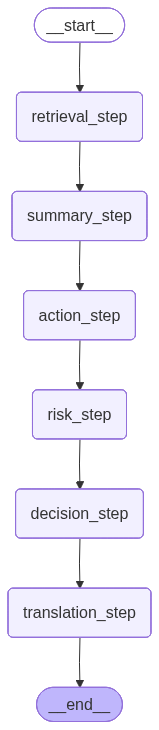

In [ ]:
# ============================================================
# LangGraph 워크플로우 시각화 레이어 (Colab 실행용)
# ============================================================
from IPython.display import Image, display

try:
    # 컴파일된 meeting_graph 객체로부터 Mermaid 형식의 PNG 이미지를 생성합니다.
    graph_png =

    print("제니가 추천하는 LangGraph 멀티 에이전트 아키텍처 구조도입니다:")
    # Colab 결과창에 이미지를 즉시 렌더링하여 보여줍니다.


except Exception as e:
    print("그래프 시각화 중 오류가 발생했습니다.")
    print("정상 출력을 위해 pygraphviz 또는 관련 패키지 설치가 필요할 수 있습니다.")
    print("에러 내용:", e)

슈퍼바이저 에이전트를 포함한 Hub-and-Spoke 아키텍처

In [ ]:
"""

슈퍼바이저 에이전트 구조

                [Gradio Audio Input]
                        ↓
                    STT (Whisper)
                        ↓
                RAG Retrieval (FAISS)
                        ↓
      ┌─────────────────────┐
      │                Supervisor Node           │
      │              (next_step 결정 AI)         │
      └─────────┬───────────┘
                          │
     ┌──────── ─┼───────────┐
     ↓            ↓        ↓              ↓
    Summary       Action    Risk        Decision
    Agent         Agent     Agent        Agent
     ↓            ↓        ↓              ↓
     └──────────┼──────────┘
                           ↓
                  Supervisor Node (재평가)
                           ↓
                (모든 작업 완료 여부 판단)
                           ↓
                 FINISH or 다음 Agent 선택
                           ↓
                    Translation Layer
                           ↓
                    Final Report Merge
                           ↓
                    Gradio Output (UI)

"""

In [ ]:
# ============================================================
# LangGraph Powered Multi-Agent System (WITH SUPERVISOR)
# - 중앙 관제탑 'Supervisor Agent' 정식 도입 -> 단순역할만 부여
# - 동적 조건부 라우팅(Conditional Edge) 아키텍처 구현
# - 한글 우선 분석 후 안전 후처리 번역 구조 완벽 유지
# ============================================================

# !pip install -q openai faiss-cpu gradio langgraph

import os                                # 시스템 환경 변수 제어용
import numpy as np                        # 임베딩 벡터 행렬 연산용
import faiss                               # 고속 벡터 검색 엔진 라이브러리
import gradio as gr                       # 웹 인터페이스 UI 구축용
import traceback                          # 런타임 에러 발생 시 추적용
import json                               # 슈퍼바이저의 구조화된 라우팅 결과 파싱용
from typing import TypedDict              # LangGraph 전역 상태 구조 정의용
from openai import OpenAI                 # 최신 OpenAI SDK 1.x 인터페이스
from google.colab import userdata        # Colab 시크릿 Key 관리자 로드용
from langgraph.graph import StateGraph, END # LangGraph 코어 컴포넌트

# ============================================================
# 1. API KEY 설정 및 클라이언트 초기화
# ============================================================
api_key = userdata.get("OPENAI_API_KEY")
os.environ["OPENAI_API_KEY"] = api_key
client = OpenAI(api_key=api_key)

# ============================================================
# 2. RAG 지식 베이스 구축 (FAISS 코어)
# ============================================================
reference_docs = [
    "회의에서는 결정사항과 실행 항목(Action Item)을 반드시 구분해야 한다.",
    "Action Item은 담당자와 마감일이 포함되어야 한다.",
    "회의 요약은 핵심 결정과 논의된 문제 중심으로 작성한다.",
    "리스크는 일정, 비용, 기술적 문제로 분류한다.",
    "결정사항은 명확하게 '결정됨' 형태로 기록한다."
]

def get_embeddings(texts):
    vectors = []


    return np.vstack(vectors)

emb =

index =

index.add(emb)

def retrieve_context(query):
    q = get_embeddings([query])
    _, idx = index.search(q, 2)
    return


# ============================================================
# 3. STT (Speech To Text)
# ============================================================
def stt(audio):
    if audio is None:
        return "NO_AUDIO"
    with open(audio, "rb") as f:
        return


# ============================================================
# 4. LANGGRAPH STATE DEFINITION (전역 공유 상태 정의)
# ============================================================
class MeetingState(TypedDict):
    audio_path: str                      # 입력받은 오디오 파일 경로
    lang: str                            # 사용자가 최종 선택한 타겟 언어
    transcript: str                      # STT 결과물 원문 텍스트
    context: str                         # RAG를 통해 확보한 기업 가이드 문맥
    summary: str                         # 요약 에이전트 결과 (한국어)
    action: str                          # 실행 항목 에이전트 결과 (한국어)
    risk: str                            # 리스크 에이전트 결과 (한국어)
    decision: str                        # 결정사항 에이전트 결과 (한국어)
    next_step: str                       # 슈퍼바이저가 지시한 다음 행선지 (라우팅 플래그)
    summary_t: str                       # 번역된 요약 리포트
    action_t: str                        # 번역된 실행 과제 리포트
    risk_t: str                          # 번역된 리스크 리포트
    decision_t: str                      # 번역된 결정 사항 리포트
    merged_raw: str                      # 병합된 한국어 원문 리포트
    merged_translated: str               # 병합된 최종 다국어 번역 리포트

# ============================================================
# 5. CORE LLM BASE CALL (에이전트 인프라 함수)
# ============================================================
def call_agent_llm(role, transcript, context):
    prompt = f"""
You are a professional enterprise AI system, acting as a {role}.
Analyze the meeting transcript strictly based on the provided reference context rules.

[Reference Context]
{context}

[Meeting Transcript]
{transcript}

[Strict Instruction]
- Provide a highly professional, structured output.
- You MUST write the entire report content in Korean (모든 내용을 반드시 한국어로 작성하세요).
- Keep the format neat and clean.
"""
    res =


    return res.choices[0].message.content.strip()

# ============================================================
# 6. LANGGRAPH NODES & SUPERVISOR (중앙 제어 및 노드 구현)
# ============================================================

def supervisor_node(state: MeetingState):
    """지휘관 에이전트: 현재 리포트 완성 상태를 보고 다음 작업을 지시하거나 끝냄 (FINISH)"""

    # 각 에이전트의 완료 여부를 체크
    status =



    prompt = f"""
You are the Supervisor Agent overseeing a team of meeting analysis experts.
Your job is to determine which expert should work next based on the current completion status.
If all experts have finished their tasks, output 'FINISH'.

[Current Status]
- Summary Agent Done: {status['summary_done']}
- Action Item Agent Done: {status['action_done']}
- Risk Agent Done: {status['risk_done']}
- Decision Agent Done: {status['decision_done']}

[Available Next Steps]
- 'summary_step': Needs to run if Summary Agent is 'NO'
- 'action_step': Needs to run if Action Item Agent is 'NO'
- 'risk_step': Needs to run if Risk Agent is 'NO'
- 'decision_step': Needs to run if Decision Agent is 'NO'
- 'FINISH': If ALL agents are 'YES'

Respond ONLY with a JSON object containing the key 'next_step'.
Example 1: {{"next_step": "summary_step"}}
Example 2: {{"next_step": "FINISH"}}
"""
    res =


    result_json =

    return {"next_step": result_json["next_step"]} # 상태에 다음 타겟 주입

def supervisor_router(state: MeetingState):
    """조건부 에지: 슈퍼바이저가 결정한 방향으로 그래프 길을 분기시킴"""

      next_step =

      if
          return "translation_step"        # 최종 목적지인 번역/병합 레이어로 보냄
    return next_step                      # 각 에이전트 노드명에 맞춰 라우팅

# 기본 인프라 단계 노드들
def rag_retrieval_node(state: MeetingState):
    transcript = stt(state["audio_path"])
    context = retrieve_context(transcript)
    return {"transcript": transcript, "context": context}

def summary_agent_node(state: MeetingState):
    res = call_agent_llm("SUMMARY AGENT (회의 핵심 요약 전문가)", state["transcript"], state["context"])
    return {"summary": res}

def action_agent_node(state: MeetingState):
    res = call_agent_llm("ACTION ITEM AGENT (실행 과제 및 기한 추출 전문가)", state["transcript"], state["context"])
    return {"action": res}

def risk_agent_node(state: MeetingState):
    res = call_agent_llm("RISK AGENT (잠재 리스크 식별 및 관리 전문가)", state["transcript"], state["context"])
    return {"risk": res}

def decision_agent_node(state: MeetingState):
    res = call_agent_llm("DECISION AGENT (핵심 의사결정 기록 전문가)", state["transcript"], state["context"])
    return {"decision": res}

# 번역 인프라 노드
def translate_core(text, lang):
    if lang == "Korean":
        return text
    res = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": f"You are a strict professional translator. Translate the given Korean text into {lang} precisely. Keep markdown structures intact."},
            {"role": "user", "content": f"Translate this into {lang}:\n\n{text}"}
        ],
        temperature=0.0
    )
    return res.choices[0].message.content.strip()

def translation_and_merge_node(state: MeetingState):
    lang = state["lang"]
    s_t = translate_core(state["summary"], lang)
    a_t = translate_core(state["action"], lang)
    r_t = translate_core(state["risk"], lang)
    d_t = translate_core(state["decision"], lang)

    merged_raw = f"MEETING REPORT (RAW)\n\n[SUMMARY]\n{state['summary']}\n\n[DECISIONS]\n{state['decision']}\n\n[ACTION ITEMS]\n{state['action']}\n\n[RISKS]\n{state['risk']}"
    merged_translated = f"MEETING REPORT ({lang.upper()})\n\n[SUMMARY]\n{s_t}\n\n[DECISIONS]\n{d_t}\n\n[ACTION ITEMS]\n{a_t}\n\n[RISKS]\n{r_t}"

    return {
        "summary_t": s_t, "action_t": a_t, "risk_t": r_t, "decision_t": d_t,
        "merged_raw": merged_raw, "merged_translated": merged_translated
    }

# ============================================================
# 7. LANGGRAPH COMPILATION (그래프 워크플로우 결합)
# ============================================================
workflow = StateGraph(MeetingState)

# 노드 등록 프로세스
workflow.add_node("retrieval_step", rag_retrieval_node)
workflow.add_node("supervisor_step", supervisor_node) # 슈퍼바이저 노드 등록
workflow.add_node("summary_step", summary_agent_node)
workflow.add_node("action_step", action_agent_node)
workflow.add_node("risk_step", risk_agent_node)
workflow.add_node("decision_step", decision_agent_node)
workflow.add_node("translation_step", translation_and_merge_node)

# 에지 배치 관계 정의 (Supervisor Hub 구조)
workflow.set_entry_point("retrieval_step")
workflow.add_edge(  ) # RAG 끝나면 무조건 지휘관에게

# 하위 에이전트들은 작업이 끝나면 무조건 관제탑(supervisor_step)으로 복귀함
workflow.add_edge(  , "supervisor_step")
workflow.add_edge(  , "supervisor_step")
workflow.add_edge(  , "supervisor_step")
workflow.add_edge(  , "supervisor_step")

# 지휘관 노드에서 상태에 따라 동적으로 분기 경로를 지정 (Conditional Edge 핵심)
workflow.add_conditional_edges(
    "supervisor_step",
    supervisor_router,
    {


    }
)
workflow.add_edge("translation_step", END)

# 실행 가능한 지능형 그래프 바이너리로 완전 컴파일
meeting_graph = workflow.compile()

# ============================================================
# 8. PIPELINE (Gradio 통제 오케스트레이터)
# ============================================================
def pipeline(audio, lang):
    try:
        initial_inputs = {
            "audio_path": audio, "lang": lang, "transcript": "", "context": "",
            "summary": "", "action": "", "risk": "", "decision": "", "next_step": "",
            "summary_t": "", "action_t": "", "risk_t": "", "decision_t": "",
            "merged_raw": "", "merged_translated": ""
        }

        # LangGraph 구동엔진 실행 (관제탑 지휘에 따라 자율 라우팅 주행)
        final_state =

        return (


        )
    except Exception:
        return "", "", "", "", "", "", "", "", traceback.format_exc()

# ============================================================
# 9. GRADIO UI LAYOUT (UI 컴포넌트 완벽 유지)
# ============================================================
with gr.Blocks() as demo:
    gr.Markdown("### Stable Supervisor-Driven Multi-Agent Meeting System")
    audio = gr.Audio(sources=["microphone", "upload"], type="filepath")
    lang = gr.Dropdown(["Korean", "English", "Japanese", "Chinese"], value="Korean")

    out1 = gr.Textbox(label="음성 인식 결과")
    out2 = gr.Textbox(label="RAG 컨텍스트")
    out3 = gr.Textbox(label="요약")
    out4 = gr.Textbox(label="액션 아이템")
    out5 = gr.Textbox(label="리스크")
    out6 = gr.Textbox(label="결정사항")
    out7 = gr.Textbox(label="원본 보고서 (RAW)")
    out8 = gr.Textbox(label="번역 보고서") # 최종 수정 대상이 노출될 다국어 번역 전용 박스
    out9 = gr.Textbox(label="에러 로그")


    btn = gr.Button("실행")

    btn.click(fn=pipeline, inputs=[audio, lang], outputs=[out1, out2, out3, out4, out5, out6, out7, out8, out9])

demo.launch(share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://dacfbee3c2e1603919.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7868 <> https://56aba7067de91c631d.gradio.live
Killing tunnel 127.0.0.1:7869 <> https://e5e227966e8221d3ba.gradio.live
Killing tunnel 127.0.0.1:7871 <> https://4b3046aabfdf6d478e.gradio.live
Killing tunnel 127.0.0.1:7872 <> https://128c8245262393de75.gradio.live
Killing tunnel 127.0.0.1:7873 <> https://7b7b7e024c20356f5e.gradio.live
Killing tunnel 127.0.0.1:7874 <> https://dacfbee3c2e1603919.gradio.live


'슈퍼바이저 기반 멀티 에이전트' 아키텍처 구조도입니다 :
------------------------------------------------------------


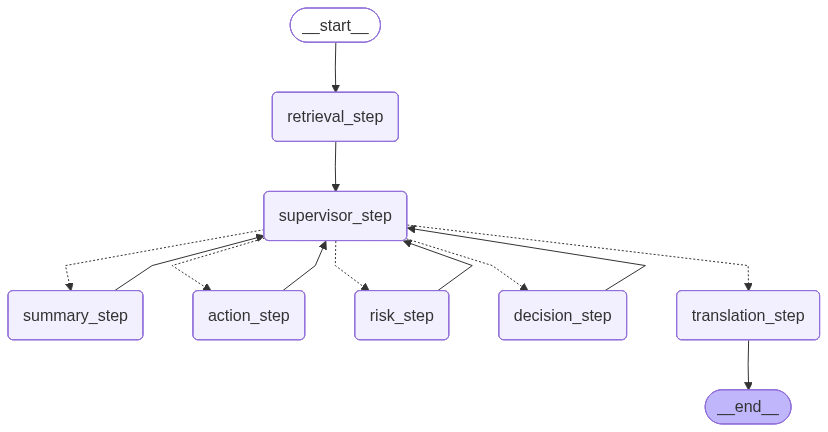

------------------------------------------------------------


In [ ]:
# ============================================================
# LangGraph 슈퍼바이저 워크플로우 시각화 레이어 (Colab 실행용)
# ============================================================
from IPython.display import Image, display

try:
    # 1. 제니가 설계한 'meeting_graph' 객체로부터 시각화 그래프를 가져옵니다.
    # 2. 'draw_mermaid_png()'를 호출하여 Mermaid 형식의 PNG 이미지로 변환합니다.
    # 만약 grandalf 패키지가 없다는 에러가 나면 아래 주석을 해제하고 먼저 실행하세요:
    # !pip install -q grandalf
    graph_png = meeting_graph.get_graph().draw_mermaid_png()

    print("'슈퍼바이저 기반 멀티 에이전트' 아키텍처 구조도입니다 :")
    print("-" * 60)

    # 3. Colab 결과창에 이미지를 즉시 렌더링하여 보여줍니다.
    display(Image(graph_png))

    print("-" * 60)

except Exception as e:
    print("그래프 시각화 중 오류가 발생했습니다 형.")
    print("정상 출력을 위해 grandalf 또는 mermaid-cli 설치가 필요할 수 있습니다.")
    print("에러 내용:", e)